In [ ]:
#all required imports
import numpy as np
import pandas as pd
import random
import shutil
import os
import numpy as np
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import matplotlib.pyplot as plt
from PIL import Image
import cv2

from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

In [2]:
def seed_worker(worker_id):
    worker_seed = seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [1]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
DATA_PATH = "/kaggle/input/datasets/shaisthaaara/cracks-and-drywall/clipseg_dataset"

metadata = pd.read_csv(f"{DATA_PATH}/metadata.csv")

metadata.head()

,image,prompt
0,crack_00002_jpg.rf.62b772deca4045ca86e9e643eee...,crack
1,crack_00016_jpg.rf.3c39913f49c5487fa2bd2c9020a...,crack
2,crack_00016_jpg.rf.27faea283288eb1e8255dad87ca...,crack
3,crack_00004_jpg.rf.8a913958495e5b20c1032dc9b6e...,crack
4,crack_00016_jpg.rf.37a52a91e9c34eefc04ccdf2094...,crack


In [4]:
crack_df = metadata[metadata.prompt == "crack"]
drywall_df = metadata[metadata.prompt == "drywall joint"]

print(len(crack_df), len(drywall_df))

# balance dataset
crack_df = crack_df.sample(len(drywall_df), random_state=42)

balanced_df = pd.concat([crack_df, drywall_df])
balanced_df = balanced_df.sample(frac=1, random_state=42)

5365 1022


In [5]:
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.30,
    stratify=balanced_df["prompt"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["prompt"],
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))

1430 307 307


In [6]:
class ClipSegDataset(Dataset):

    def __init__(self, dataframe, processor, image_dir, mask_dir):
        self.df = dataframe.reset_index(drop=True)
        self.processor = processor
        self.image_dir = image_dir
        self.mask_dir = mask_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = f"{self.image_dir}/{row.image}"
        mask_path = f"{self.mask_dir}/{row.image.replace('.jpg','.png')}"

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path)

        mask = np.array(mask) / 255.0
        mask = cv2.resize(mask, (352, 352), interpolation=cv2.INTER_NEAREST)
        mask = torch.tensor(mask).float()

        inputs = self.processor(
            text=row.prompt,
            images=image,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        inputs = {k:v.squeeze() for k,v in inputs.items()}
        inputs["labels"] = mask

        return inputs

In [7]:
processor = CLIPSegProcessor.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
)

model = CLIPSegForImageSegmentation.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
)

preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
IMAGE_DIR = f"{DATA_PATH}/images"
MASK_DIR = f"{DATA_PATH}/masks"

train_dataset = ClipSegDataset(train_df, processor, IMAGE_DIR, MASK_DIR)
val_dataset = ClipSegDataset(val_df, processor, IMAGE_DIR, MASK_DIR)
test_dataset = ClipSegDataset(test_df, processor, IMAGE_DIR, MASK_DIR)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    worker_init_fn=seed_worker
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    worker_init_fn=seed_worker
)

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)

optimizer = AdamW(model.parameters(), lr=1e-5)

In [10]:
EPOCHS = 100

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):

        batch = {k:v.to(device) for k,v in batch.items()}

        outputs = model(**batch)

        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} loss:", total_loss / len(train_loader))

100%|██████████| 90/90 [00:58<00:00,  1.53it/s]


Epoch 1 loss: 0.30943251185946996


100%|██████████| 90/90 [00:48<00:00,  1.85it/s]


Epoch 2 loss: 0.2846900933318668


100%|██████████| 90/90 [00:48<00:00,  1.86it/s]


...

Epoch 98 loss: 0.11687911314268908


100%|██████████| 90/90 [00:49<00:00,  1.81it/s]


Epoch 99 loss: 0.11687284029192395


100%|██████████| 90/90 [00:49<00:00,  1.81it/s]

Epoch 100 loss: 0.11660171962446636


In [12]:
def compute_metrics(pred, target):

    pred = pred > 0.5
    target = target > 0.5

    intersection = (pred & target).sum().item()
    union = (pred | target).sum().item()

    iou = intersection / (union + 1e-8)
    dice = (2 * intersection) / (pred.sum().item() + target.sum().item() + 1e-8)

    return iou, dice


model.eval()

iou_scores = []
dice_scores = []

with torch.no_grad():

    for batch in tqdm(val_loader):

        batch = {k:v.to(device) for k,v in batch.items()}

        outputs = model(**batch)

        preds = torch.sigmoid(outputs.logits)

        preds = preds.cpu()
        masks = batch["labels"].cpu()

        for p, m in zip(preds, masks):

            iou, dice = compute_metrics(p, m)

            iou_scores.append(iou)
            dice_scores.append(dice)

print("Validation IoU :", np.mean(iou_scores))
print("Validation Dice:", np.mean(dice_scores))

100%|██████████| 20/20 [00:14<00:00,  1.41it/s]

Validation IoU : 0.4501630450935771
Validation Dice: 0.5929926684818894


In [15]:
prompt_metrics = {
    "crack": {"iou": [], "dice": []},
    "drywall joint": {"iou": [], "dice": []}
}

model.eval()

with torch.no_grad():

    for batch_idx, batch in enumerate(val_loader):

        prompts = val_df.iloc[
            batch_idx*val_loader.batch_size :
            batch_idx*val_loader.batch_size + len(batch["labels"])
        ]["prompt"].values

        batch = {k:v.to(device) for k,v in batch.items()}

        outputs = model(**batch)

        preds = torch.sigmoid(outputs.logits).cpu()
        masks = batch["labels"].cpu()

        for pred, mask, prompt in zip(preds, masks, prompts):

            pred = pred > 0.5
            mask = mask > 0.5

            intersection = (pred & mask).sum().item()
            union = (pred | mask).sum().item()

            iou = intersection / (union + 1e-8)
            dice = (2 * intersection) / (
                pred.sum().item() + mask.sum().item() + 1e-8
            )

            prompt_metrics[prompt]["iou"].append(iou)
            prompt_metrics[prompt]["dice"].append(dice)

In [16]:
for prompt in prompt_metrics:

    iou = np.mean(prompt_metrics[prompt]["iou"])
    dice = np.mean(prompt_metrics[prompt]["dice"])

    print(prompt)
    print(" IoU :", iou)
    print(" Dice:", dice)
    print()

crack
 IoU : 0.37178725834936227
 Dice: 0.5161906138278525

drywall joint
 IoU : 0.5280298981576347
 Dice: 0.6692960084953158



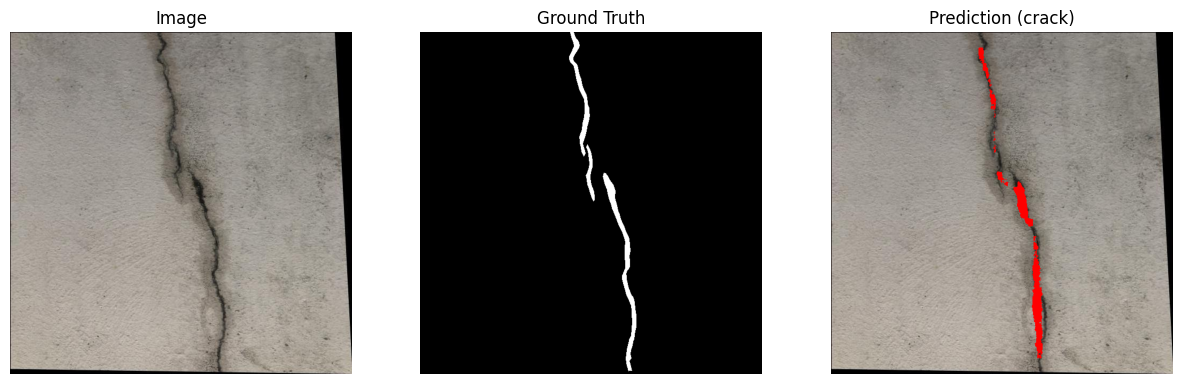

In [34]:
model.eval()

# pick random image
row = val_df.sample(1).iloc[0]

image_path = f"{IMAGE_DIR}/{row.image}"
mask_path = f"{MASK_DIR}/{row.image.replace('.jpg','.png')}"

image = Image.open(image_path).convert("RGB")
gt_mask = Image.open(mask_path)

# change prompt here
prompt = "crack"

inputs = processor(
    text=prompt,
    images=image,
    return_tensors="pt",
    padding="max_length"
)

inputs = {k:v.to(device) for k,v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

pred = torch.sigmoid(outputs.logits).cpu().squeeze().numpy()

pred = cv2.resize(pred, (image.size[0], image.size[1]))

gt_mask = np.array(gt_mask)/255.0

pred_binary = pred > 0.5

overlay = np.array(image).copy()
overlay[pred_binary] = [255,0,0]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(gt_mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title(f"Prediction ({prompt})")
plt.imshow(overlay)
plt.axis("off")

plt.show()

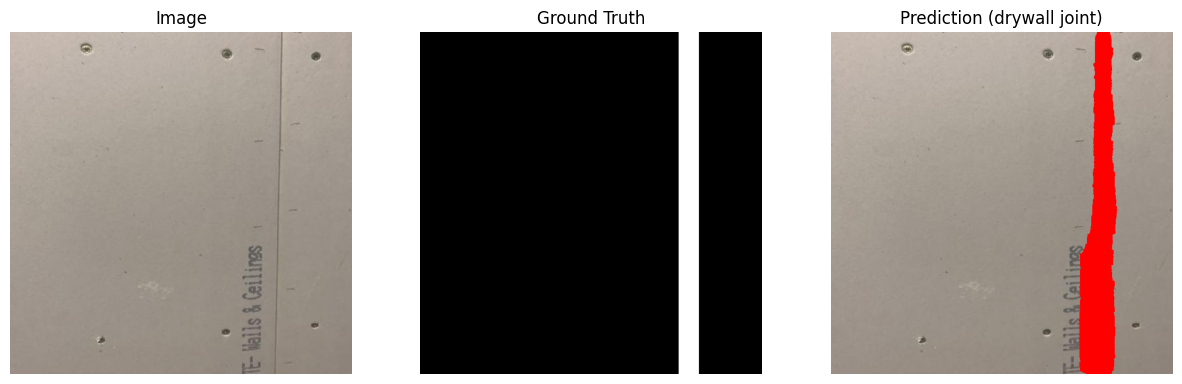

In [35]:
model.eval()

# pick random image
row = val_df.sample(1).iloc[0]

image_path = f"{IMAGE_DIR}/{row.image}"
mask_path = f"{MASK_DIR}/{row.image.replace('.jpg','.png')}"

image = Image.open(image_path).convert("RGB")
gt_mask = Image.open(mask_path)

# change prompt here
prompt = "drywall joint"

inputs = processor(
    text=prompt,
    images=image,
    return_tensors="pt",
    padding="max_length"
)

inputs = {k:v.to(device) for k,v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

pred = torch.sigmoid(outputs.logits).cpu().squeeze().numpy()

pred = cv2.resize(pred, (image.size[0], image.size[1]))

gt_mask = np.array(gt_mask)/255.0

pred_binary = pred > 0.5

overlay = np.array(image).copy()
overlay[pred_binary] = [255,0,0]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(gt_mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title(f"Prediction ({prompt})")
plt.imshow(overlay)
plt.axis("off")

plt.show()

In [ ]:
model.eval()

OUTPUT_DIR = "prediction_masks"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for _, row in tqdm(val_df.iterrows(), total=len(val_df)):

    image_path = f"{IMAGE_DIR}/{row.image}"
    image = Image.open(image_path).convert("RGB")

    prompt = row.prompt

    inputs = processor(
        text=prompt,
        images=image,
        return_tensors="pt",
        padding="max_length"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.sigmoid(outputs.logits).cpu().squeeze().numpy()

    # resize to original image size
    pred = cv2.resize(pred, (image.size[0], image.size[1]))

    # convert to binary {0,255}
    pred_binary = (pred > 0.5).astype(np.uint8) * 255

    # filename formatting
    image_id = row.image.split(".")[0]
    prompt_clean = prompt.replace(" ", "_")

    filename = f"{image_id}__{prompt_clean}.png"

    save_path = os.path.join(OUTPUT_DIR, filename)

    Image.fromarray(pred_binary).save(save_path)

print("All prediction masks saved to:", OUTPUT_DIR)

100%|██████████| 307/307 [00:16<00:00, 19.01it/s]

All prediction masks saved to: prediction_masks


In [17]:
#saving the model
model.save_pretrained("/kaggle/working/clipseg_model")
processor.save_pretrained("/kaggle/working/clipseg_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['/kaggle/working/clipseg_model/processor_config.json']

In [39]:
shutil.make_archive(
    "/kaggle/working/prediction_masks",
    'zip',
    "/kaggle/working/prediction_masks"
)

print("Zip file created!")

Zip file created!
